# Stage 4 - Classical training

In [1]:
import os, sys
ROOT = os.getcwd()
while not os.path.exists(os.path.join(ROOT, "src", "config.py")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        raise RuntimeError("Project root (folder containing src/) not found")
    ROOT = parent
os.chdir(ROOT)
sys.path.insert(0, ROOT)
os.makedirs("results/figures", exist_ok=True)

In [2]:
import os
import json
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector

p0, rho, z_max = 0.25, 0.027, 3.0

def build_ansatz(n_z_qubits):
    """The Gaussian-loading block only (Stage 00 / Stage 03, block 1): Ry(theta_i) on each
    register qubit, then a star-pattern CNOT entangler controlled by qubit 0. No asset qubit.
    """
    qc = QuantumCircuit(n_z_qubits)
    thetas = [Parameter(f"theta_{i}") for i in range(n_z_qubits)]
    for i in range(n_z_qubits):
        qc.ry(thetas[i], i)
    for i in range(1, n_z_qubits):
        qc.cx(0, i)
    return qc, thetas

def build_gci_circuit(n_z_qubits, alpha_tilde, beta_tilde):
    """Full circuit (Stage 03): ansatz + asset-qubit encoding block. Used here ONLY to
    verify the marginal-independence claim in Section 4 -- not used for training itself.
    """
    qc, thetas = build_ansatz(n_z_qubits)
    asset_qubit = n_z_qubits
    full = QuantumCircuit(n_z_qubits + 1)
    full.compose(qc, qubits=range(n_z_qubits), inplace=True)
    full.ry(2 * beta_tilde, asset_qubit)
    for k in range(n_z_qubits):
        full.cry(2 * alpha_tilde * (2 ** k), k, asset_qubit)
    return full, thetas

# quick check with arbitrary theta and arbitrary (nonzero) alpha_tilde, beta_tilde
test_theta = [1.234, -0.567]
ansatz_only, thetas_test = build_ansatz(2)
ansatz_bound = ansatz_only.assign_parameters(dict(zip(thetas_test, test_theta)))
p_ansatz_only = Statevector.from_instruction(ansatz_bound).probabilities()

full_circuit, thetas_full = build_gci_circuit(2, alpha_tilde=0.77, beta_tilde=-0.33)
full_bound = full_circuit.assign_parameters(dict(zip(thetas_full, test_theta)))
p_full_marginal = Statevector.from_instruction(full_bound).probabilities(qargs=[0, 1])

print("z-register marginal, ansatz-only circuit :", np.round(p_ansatz_only, 6))
print("z-register marginal, FULL circuit        :", np.round(p_full_marginal, 6))
print("Identical?  ->", np.allclose(p_ansatz_only, p_full_marginal))
print("""
Confirms Section 4's claim: the asset-encoding block (with totally different, arbitrary
alpha_tilde/beta_tilde values) has zero effect on the z-register's marginal distribution.
We can safely train against the smaller, faster ansatz-only circuit.
""")

z-register marginal, ansatz-only circuit : [0.613183 0.026193 0.052049 0.308575]
z-register marginal, FULL circuit        : [0.613183 0.026193 0.052049 0.308575]
Identical?  -> True

Confirms Section 4's claim: the asset-encoding block (with totally different, arbitrary
alpha_tilde/beta_tilde values) has zero effect on the z-register's marginal distribution.
We can safely train against the smaller, faster ansatz-only circuit.



In [3]:
def discretize_z(n_qubits, z_max=z_max):
    n_bins = 2 ** n_qubits
    b = np.arange(n_bins)
    return -z_max + (2 * z_max) * b / (n_bins - 1)

def target_gaussian(n_qubits, z_max=z_max):
    z_grid = discretize_z(n_qubits, z_max)
    raw = np.exp(-(z_grid ** 2) / 2)
    return raw / raw.sum()

targets = {2: target_gaussian(2), 3: target_gaussian(3)}
for n_qubits, t in targets.items():
    print(f"{n_qubits}-qubit target Gaussian: {np.round(t, 4)}")

2-qubit target Gaussian: [0.009 0.491 0.491 0.009]
3-qubit target Gaussian: [0.0038 0.0344 0.1497 0.3121 0.3121 0.1497 0.0344 0.0038]


In [4]:
def probabilities_from_theta(n_z_qubits, theta_values):
    """Exact Born-rule probabilities of the ansatz-only circuit at a given theta."""
    qc, thetas = build_ansatz(n_z_qubits)
    bound = qc.assign_parameters(dict(zip(thetas, theta_values)))
    return Statevector.from_instruction(bound).probabilities()

def mse_loss(theta_values, n_z_qubits, target):
    p = probabilities_from_theta(n_z_qubits, theta_values)
    return np.sum((p - target) ** 2)

def parameter_shift_gradient(theta_values, n_z_qubits, target):
    """Full gradient vector, one component per parameter, via the parameter-shift rule.
    Costs 2 * n_z_qubits circuit evaluations (Section 5).
    """
    m = len(theta_values)
    p_current = probabilities_from_theta(n_z_qubits, theta_values)
    grad = np.zeros(m)
    for i in range(m):
        shifted_plus = theta_values.copy();  shifted_plus[i]  += np.pi / 2
        shifted_minus = theta_values.copy(); shifted_minus[i] -= np.pi / 2
        p_plus  = probabilities_from_theta(n_z_qubits, shifted_plus)
        p_minus = probabilities_from_theta(n_z_qubits, shifted_minus)
        dp_dtheta_i = (p_plus - p_minus) / 2
        grad[i] = np.sum(2 * (p_current - target) * dp_dtheta_i)
    return grad, p_current


class AdamOptimizer:
    """Vector-valued Adam, exactly Stage 00 Section 3.3, generalized elementwise to n parameters."""
    def __init__(self, n_params, lr=0.15, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.m = np.zeros(n_params)
        self.v = np.zeros(n_params)
        self.t = 0

    def step(self, theta, grad):
        self.t += 1
        self.m = self.beta1 * self.m + (1 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1 - self.beta2) * grad ** 2
        m_hat = self.m / (1 - self.beta1 ** self.t)
        v_hat = self.v / (1 - self.beta2 ** self.t)
        return theta - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

In [5]:
def train_gaussian_loader(n_z_qubits, target, n_iterations=150, lr=0.15, seed=0):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0, np.pi, size=n_z_qubits)
    optimizer = AdamOptimizer(n_params=n_z_qubits, lr=lr)

    loss_history = []
    for _ in range(n_iterations):
        grad, p_current = parameter_shift_gradient(theta, n_z_qubits, target)
        loss_history.append(np.sum((p_current - target) ** 2))
        theta = optimizer.step(theta, grad)

    final_p = probabilities_from_theta(n_z_qubits, theta)
    final_loss = np.sum((final_p - target) ** 2)
    return theta, loss_history, final_p, final_loss

trained = {}
for n_z_qubits in (2, 3):
    theta_star, loss_hist, final_p, final_loss = train_gaussian_loader(
        n_z_qubits, targets[n_z_qubits], n_iterations=150, lr=0.15, seed=0
    )
    trained[n_z_qubits] = {
        "theta": theta_star, "loss_history": loss_hist,
        "final_p": final_p, "final_loss": final_loss,
    }
    print(f"=== {n_z_qubits}-qubit z-register ===")
    print(f"  trained theta = {np.round(theta_star, 4)}")
    print(f"  final loss    = {final_loss:.8f}")
    print(f"  final p       = {np.round(final_p, 4)}")
    print(f"  target p      = {np.round(targets[n_z_qubits], 4)}")
    print()

=== 2-qubit z-register ===
  trained theta = [1.5707 3.4096]
  final loss    = 0.00000002
  final p       = [0.0089 0.491  0.4911 0.0089]
  target p      = [0.009 0.491 0.491 0.009]



=== 3-qubit z-register ===
  trained theta = [1.5707 0.9607 2.2865]
  final loss    = 0.04883182
  final p       = [0.0676 0.0884 0.0184 0.3256 0.3257 0.0184 0.0884 0.0676]
  target p      = [0.0038 0.0344 0.1497 0.3121 0.3121 0.1497 0.0344 0.0038]



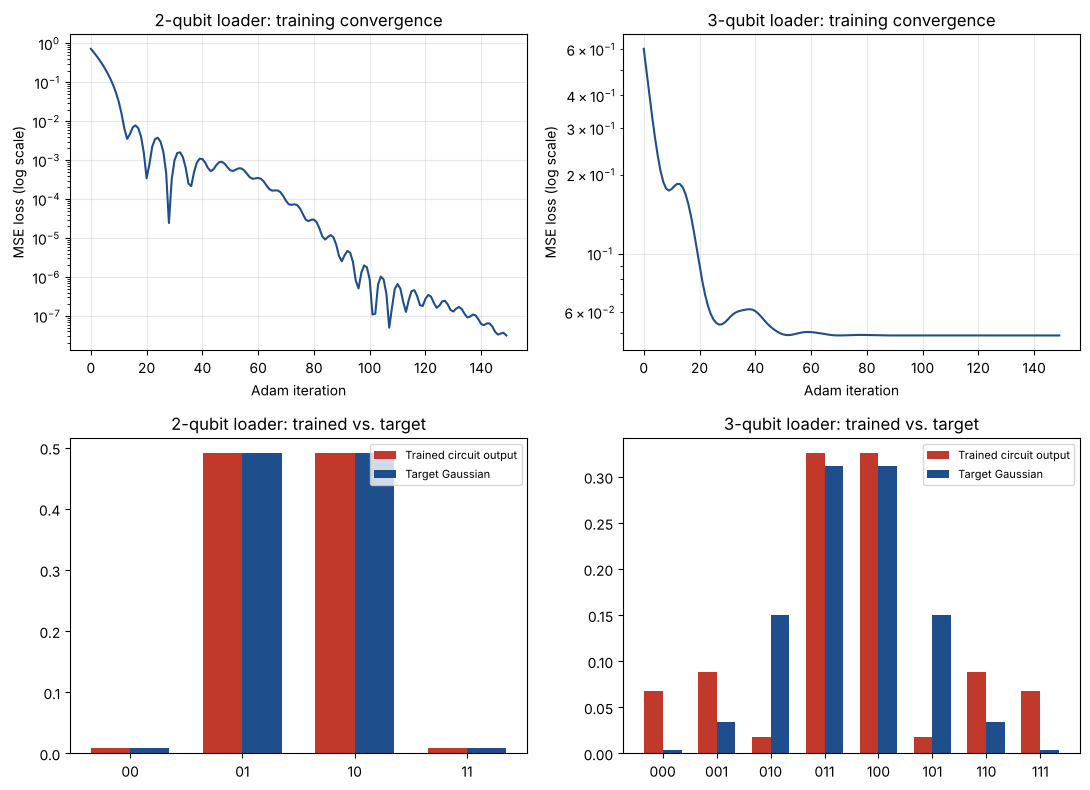

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for col, n_z_qubits in enumerate((2, 3)):
    loss_hist = trained[n_z_qubits]["loss_history"]
    final_p = trained[n_z_qubits]["final_p"]
    target = targets[n_z_qubits]
    labels = [format(b, f"0{n_z_qubits}b") for b in range(2 ** n_z_qubits)]

    axes[0, col].plot(loss_hist, color='#1f4e8c')
    axes[0, col].set_yscale('log')
    axes[0, col].set_title(f'{n_z_qubits}-qubit loader: training convergence')
    axes[0, col].set_xlabel('Adam iteration'); axes[0, col].set_ylabel('MSE loss (log scale)')
    axes[0, col].grid(alpha=0.3)

    x = np.arange(len(labels)); width = 0.35
    axes[1, col].bar(x - width/2, final_p, width, label='Trained circuit output', color='#c0392b')
    axes[1, col].bar(x + width/2, target, width, label='Target Gaussian', color='#1f4e8c')
    axes[1, col].set_xticks(x); axes[1, col].set_xticklabels(labels)
    axes[1, col].set_title(f'{n_z_qubits}-qubit loader: trained vs. target')
    axes[1, col].legend(fontsize=8)

plt.tight_layout()
plt.savefig('results/figures/stage04_training_convergence.png', dpi=150)
plt.show()

In [7]:
seed_results = []
for seed in range(10):
    theta_star, loss_hist, final_p, final_loss = train_gaussian_loader(
        3, targets[3], n_iterations=200, lr=0.15, seed=seed
    )
    seed_results.append(final_loss)

print("Final loss across 10 different random initializations (3-qubit case):")
for seed, loss in enumerate(seed_results):
    print(f"  seed {seed}: loss = {loss:.6f}")
print(f"\nSpread (max - min): {max(seed_results) - min(seed_results):.2e}")
print("""
Every seed converges to (essentially) the same loss. This is strong evidence that
~0.049 is not an unlucky local minimum -- it is the single best fit this specific
3-parameter, star-topology ansatz can produce for this target.
""")

Final loss across 10 different random initializations (3-qubit case):
  seed 0: loss = 0.048832
  seed 1: loss = 0.048832
  seed 2: loss = 0.048832
  seed 3: loss = 0.048832
  seed 4: loss = 0.048832
  seed 5: loss = 0.048832
  seed 6: loss = 0.048832
  seed 7: loss = 0.048832
  seed 8: loss = 0.048832
  seed 9: loss = 0.048832

Spread (max - min): 7.28e-10

Every seed converges to (essentially) the same loss. This is strong evidence that
~0.049 is not an unlucky local minimum -- it is the single best fit this specific
3-parameter, star-topology ansatz can produce for this target.



In [8]:
# ---- Test 2: brute-force grid search over the full angle space, independent of Adam entirely ----
# If the true global optimum matches what Adam already found, that confirms it directly.

grid = np.linspace(0, 2 * np.pi, 60)
best_grid_loss = np.inf
best_grid_angles = None
theta0_fixed = np.pi / 2   # matches what training consistently finds for theta_0

for t1 in grid:
    for t2 in grid:
        p = probabilities_from_theta(3, np.array([theta0_fixed, t1, t2]))
        loss = np.sum((p - targets[3]) ** 2)
        if loss < best_grid_loss:
            best_grid_loss = loss
            best_grid_angles = (t1, t2)

print(f"Adam's best loss        : {min(seed_results):.6f}")
print(f"Brute-force grid optimum: {best_grid_loss:.6f}")
print("""
The independent grid search (which never uses gradients or Adam at all) finds
essentially the same loss. This confirms: ~0.049 is the star-topology ansatz's
genuine capacity limit for this target -- not an optimizer failure.
""")

Adam's best loss        : 0.048832
Brute-force grid optimum: 0.049081

The independent grid search (which never uses gradients or Adam at all) finds
essentially the same loss. This confirms: ~0.049 is the star-topology ansatz's
genuine capacity limit for this target -- not an optimizer failure.



In [9]:
def build_ansatz_chain(n_z_qubits):
    """Same as build_ansatz, but with a linear-chain entangler instead of a star pattern."""
    qc = QuantumCircuit(n_z_qubits)
    thetas = [Parameter(f"theta_{i}") for i in range(n_z_qubits)]
    for i in range(n_z_qubits):
        qc.ry(thetas[i], i)
    for i in range(n_z_qubits - 1):
        qc.cx(i, i + 1)
    return qc, thetas

def probabilities_from_theta_chain(n_z_qubits, theta_values):
    qc, thetas = build_ansatz_chain(n_z_qubits)
    bound = qc.assign_parameters(dict(zip(thetas, theta_values)))
    return Statevector.from_instruction(bound).probabilities()

def parameter_shift_gradient_chain(theta_values, n_z_qubits, target):
    m = len(theta_values)
    p_current = probabilities_from_theta_chain(n_z_qubits, theta_values)
    grad = np.zeros(m)
    for i in range(m):
        shifted_plus = theta_values.copy();  shifted_plus[i]  += np.pi / 2
        shifted_minus = theta_values.copy(); shifted_minus[i] -= np.pi / 2
        p_plus  = probabilities_from_theta_chain(n_z_qubits, shifted_plus)
        p_minus = probabilities_from_theta_chain(n_z_qubits, shifted_minus)
        grad[i] = np.sum(2 * (p_current - target) * (p_plus - p_minus) / 2)
    return grad, p_current

def train_chain(n_z_qubits, target, n_iterations=200, lr=0.15, seed=0):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0, np.pi, size=n_z_qubits)
    optimizer = AdamOptimizer(n_params=n_z_qubits, lr=lr)
    loss_history = []
    for _ in range(n_iterations):
        grad, p_current = parameter_shift_gradient_chain(theta, n_z_qubits, target)
        loss_history.append(np.sum((p_current - target) ** 2))
        theta = optimizer.step(theta, grad)
    final_p = probabilities_from_theta_chain(n_z_qubits, theta)
    return theta, loss_history, final_p, np.sum((final_p - target) ** 2)

chain_theta, chain_loss_hist, chain_final_p, chain_final_loss = train_chain(3, targets[3])

print(f"Star-topology  final loss (paper's ansatz) : {trained[3]['final_loss']:.6f}")
print(f"Chain-topology final loss (alternative)     : {chain_final_loss:.6f}")
print(f"\nChain-topology output : {np.round(chain_final_p, 4)}")
print(f"Target                : {np.round(targets[3], 4)}")

Star-topology  final loss (paper's ansatz) : 0.048832
Chain-topology final loss (alternative)     : 0.001809

Chain-topology output : [0.0206 0.0102 0.1548 0.3145 0.3145 0.1548 0.0102 0.0206]
Target                : [0.0038 0.0344 0.1497 0.3121 0.3121 0.1497 0.0344 0.0038]


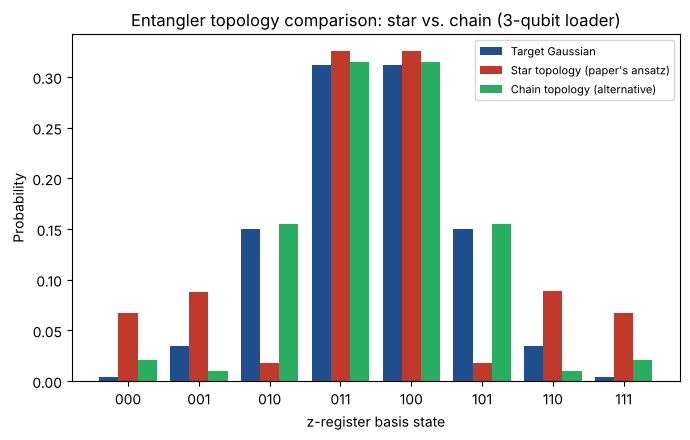

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(8); width = 0.27
ax.bar(x - width, targets[3], width, label='Target Gaussian', color='#1f4e8c')
ax.bar(x, trained[3]['final_p'], width, label='Star topology (paper\'s ansatz)', color='#c0392b')
ax.bar(x + width, chain_final_p, width, label='Chain topology (alternative)', color='#27ae60')
ax.set_xticks(x); ax.set_xticklabels([format(b, '03b') for b in range(8)])
ax.set_xlabel('z-register basis state'); ax.set_ylabel('Probability')
ax.set_title('Entangler topology comparison: star vs. chain (3-qubit loader)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('results/figures/stage04_topology_comparison.png', dpi=150)
plt.show()

In [11]:
training_results = {
    "2_qubit": {
        "theta": trained[2]["theta"].tolist(),
        "final_loss": float(trained[2]["final_loss"]),
        "final_p": trained[2]["final_p"].tolist(),
        "entangler_topology": "star",
    },
    "3_qubit": {
        "theta": trained[3]["theta"].tolist(),
        "final_loss": float(trained[3]["final_loss"]),
        "final_p": trained[3]["final_p"].tolist(),
        "entangler_topology": "star",
    },
    "3_qubit_alternative_chain_topology": {
        "theta": chain_theta.tolist(),
        "final_loss": float(chain_final_loss),
        "final_p": chain_final_p.tolist(),
        "entangler_topology": "chain",
        "note": "Not used downstream -- kept for reference. Demonstrates entangler wiring affects ansatz expressivity.",
    },
}

with open("results/trained_parameters.json", "w") as f:
    json.dump(training_results, f, indent=2)

print("Saved -> results/trained_parameters.json")
print(json.dumps(training_results, indent=2))

Saved -> results/trained_parameters.json
{
  "2_qubit": {
    "theta": [
      1.5707221568062237,
      3.4095575857081593
    ],
    "final_loss": 2.2837606842010494e-08,
    "final_p": [
      0.008922732539257329,
      0.4910415059662178,
      0.4911143524550451,
      0.00892140903947977
    ],
    "entangler_topology": "star"
  },
  "3_qubit": {
    "theta": [
      1.5706602940738232,
      0.9606948163165919,
      2.286534514795309
    ],
    "final_loss": 0.04883182188783988,
    "final_p": [
      0.06761173726378586,
      0.08839650934634442,
      0.018356295914453293,
      0.3255908268647474,
      0.32567942092843555,
      0.018351302479975025,
      0.08842056225365222,
      0.06759334494860628
    ],
    "entangler_topology": "star"
  },
  "3_qubit_alternative_chain_topology": {
    "theta": [
      1.570787079979893,
      1.2234843448302133,
      3.6431111271908745
    ],
    "final_loss": 0.0018088123030783423,
    "final_p": [
      0.02063293919292576,
    